In [1]:
import torch, os
import torch.nn as nn
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
import torch
from PIL import Image
from PIL import ImageFile
import numpy as np
import random
import timm
import yaml
from sklearn.manifold import TSNE
from sklearn.mixture import GaussianMixture

# === Hyperparameters ===
model_name = "resnet18"
config_path = f"FastFlow/configs/{model_name}.yaml"
config = yaml.safe_load(open(config_path, "r"))
print("Model config: ", config)


# === Model Setup ===
model = timm.create_model(model_name, pretrained=True, features_only=True, in_chans=3, out_indices=[1, 2, 3])
model.eval()

channels = model.feature_info.channels()
print("Channels: ", channels)
scales = model.feature_info.reduction()
print("Scales: ", scales)

# === Get features ===
def get_features(img):
    img = torch.from_numpy(np.array(img)).permute(2, 0, 1).unsqueeze(0).float()
    with torch.no_grad():
        features = model(img)
    return features

def get_features_from_path(path): 
    img = np.array(Image.open(path).convert("RGB").resize([config['input_size'],config['input_size']]))
    feature = get_features(img)  # (C, H, W)
    return feature  # (C,)

# def get_features_from_path(path):
#     img = plt.imread(path)[:,:,:3]
#     return get_features(img)


def calculate_fourier_spectrum(image):
    f = np.fft.fft2(image)
    fshift = np.fft.fftshift(f)
    magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1)
    #phase_spectrum = np.angle(fshift)
    return magnitude_spectrum

Model config:  {'input_size': 256, 'backbone_name': 'resnet18', 'flow_step': 8, 'hidden_ratio': 1.0, 'conv3x3_only': True}
Channels:  [64, 128, 256]
Scales:  [4, 8, 16]


## Image Analysis

In [36]:
common_path = "/media/orazio_mattia_group/ad4dd/FF4ALL"
generators = []
patterns = {}

# Get generators from Closed Set
closed_set_path = os.path.join(common_path, 'Closed Set')
if os.path.exists(closed_set_path):
    generators = [folder for folder in os.listdir(closed_set_path) 
                      if os.path.isdir(os.path.join(closed_set_path, folder))]
for gen in generators:
    patterns[gen] = os.path.join(closed_set_path, gen, '*.png')

# Get generators from Open Set
open_set_path = os.path.join(common_path, 'Open Set')
if os.path.exists(open_set_path):
    generators = [folder for folder in os.listdir(open_set_path) 
                      if os.path.isdir(os.path.join(open_set_path, folder))]

for gen in generators:
    patterns[gen] = os.path.join(open_set_path, gen, '*.png')

patterns['ffhq'] = '/media/orazio_mattia_group/ad4dd/ffhq/*/*.png'
patterns['celeba_hq'] = '/media/orazio_mattia_group/ad4dd/celeba_hq/*/*/*.jpg'

patterns

{'Flux.1': '/media/orazio_mattia_group/ad4dd/FF4ALL/Closed Set/Flux.1/*.png',
 'Stable DIffusion 3.5': '/media/orazio_mattia_group/ad4dd/FF4ALL/Closed Set/Stable DIffusion 3.5/*.png',
 'Starry AI': '/media/orazio_mattia_group/ad4dd/FF4ALL/Closed Set/Starry AI/*.png',
 'Stable Diffusion XL': '/media/orazio_mattia_group/ad4dd/FF4ALL/Closed Set/Stable Diffusion XL/*.png',
 'Midjourney': '/media/orazio_mattia_group/ad4dd/FF4ALL/Closed Set/Midjourney/*.png',
 'Flux.1.1 Pro': '/media/orazio_mattia_group/ad4dd/FF4ALL/Closed Set/Flux.1.1 Pro/*.png',
 'Dall-E 3': '/media/orazio_mattia_group/ad4dd/FF4ALL/Closed Set/Dall-E 3/*.png',
 'StyleGAN3': '/media/orazio_mattia_group/ad4dd/FF4ALL/Open Set/StyleGAN3/*.png',
 'Stable Diffusion Attend and Excite': '/media/orazio_mattia_group/ad4dd/FF4ALL/Open Set/Stable Diffusion Attend and Excite/*.png',
 'Stable Cascade': '/media/orazio_mattia_group/ad4dd/FF4ALL/Open Set/Stable Cascade/*.png',
 'Deep AI': '/media/orazio_mattia_group/ad4dd/FF4ALL/Open Set/De

In [37]:
flux_1 = glob(patterns['Flux.1'])
ffhq = glob(patterns['ffhq'])
stable_diffusion_35 = glob(patterns['Stable DIffusion 3.5'])
starry_ai = glob(patterns['Starry AI'])
stylegan3 = glob(patterns['StyleGAN3'])
stable_diffusion_xl = glob(patterns['Stable Diffusion XL'])
attend_and_excite = glob(patterns['Stable Diffusion Attend and Excite'])
midjourney = glob(patterns['Midjourney'])
stable_cascade = glob(patterns['Stable Cascade'])
flux_1_1_pro = glob(patterns['Flux.1.1 Pro'])
deep_ai = glob(patterns['Deep AI'])
stylegan2 = glob(patterns['StyleGAN2'])
celeba_hq = glob(patterns['celeba_hq'])
hotpot_ai = glob(patterns['Hotpot AI'])
tencent_hunyuan = glob(patterns['Tencent Hunyuan'])
dalle_3 = glob(patterns['Dall-E 3'])
stylegan = glob(patterns['StyleGAN'])
nvidia_sana_pag = glob(patterns['Nvidia Sana PAG'])

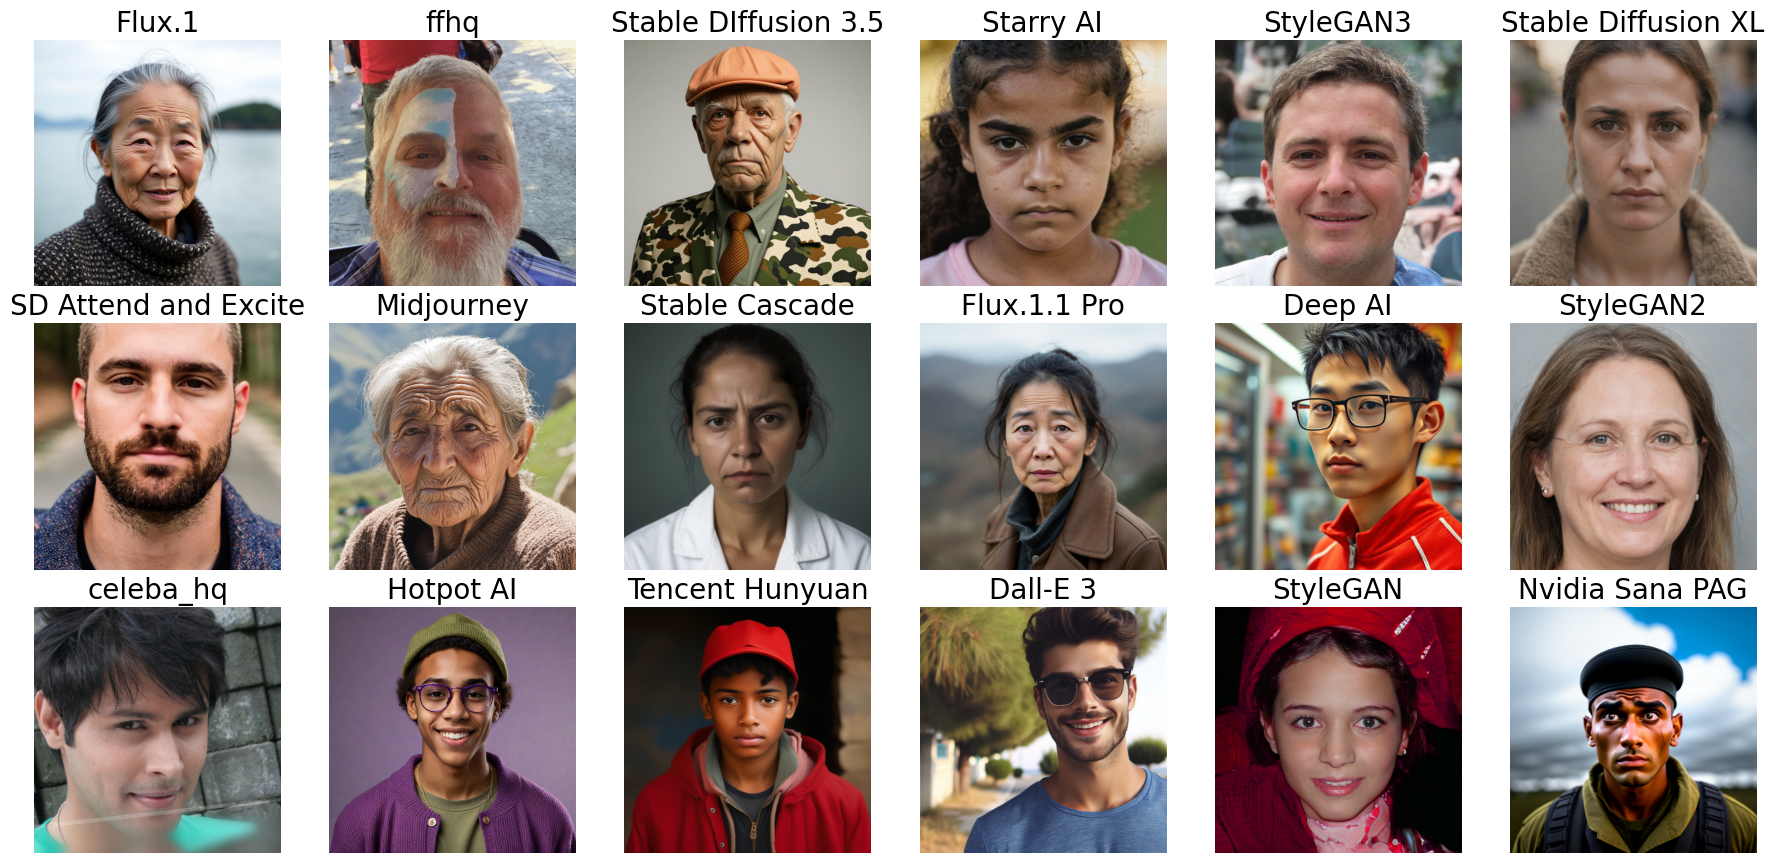

In [46]:
# Dizionario generatori -> liste immagini (ottenute con glob)
generators_dict = {
    'Flux.1': flux_1,
    'ffhq': ffhq,
    'Stable DIffusion 3.5': stable_diffusion_35,
    'Starry AI': starry_ai,
    'StyleGAN3': stylegan3,
    'Stable Diffusion XL': stable_diffusion_xl,
    'SD Attend and Excite': attend_and_excite,
    'Midjourney': midjourney,
    'Stable Cascade': stable_cascade,
    'Flux.1.1 Pro': flux_1_1_pro,
    'Deep AI': deep_ai,
    'StyleGAN2': stylegan2,
    'celeba_hq': celeba_hq,
    'Hotpot AI': hotpot_ai,
    'Tencent Hunyuan': tencent_hunyuan,
    'Dall-E 3': dalle_3,
    'StyleGAN': stylegan,
    'Nvidia Sana PAG': nvidia_sana_pag
}

# Griglia: calcola righe e colonne in base al numero totale
num_generators = len(generators_dict)
cols = 6
rows = (num_generators + cols - 1) // cols

plt.figure(figsize=(3 * cols, 3 * rows))

for idx, (name, img_list) in enumerate(generators_dict.items()):
    if not img_list:
        continue

    # Seleziona immagine casuale
    img_path = random.choice(img_list)
    try:
        img = Image.open(img_path).convert("RGB")
        img_tensor = torch.from_numpy(np.array(img)).permute(2, 0, 1).float() / 255

        ax = plt.subplot(rows, cols, idx + 1)
        ax.imshow(img_tensor.permute(1, 2, 0))
        ax.set_title(name, fontsize=20)
        ax.axis('off')

    except Exception as e:
        print(f"Errore con immagine {img_path}: {e}")
        continue

plt.tight_layout()
plt.subplots_adjust(top=0.92, hspace=0.15, wspace=0.001)
plt.show()

Applying t-SNE for layer 2...
Plotting layer 0...


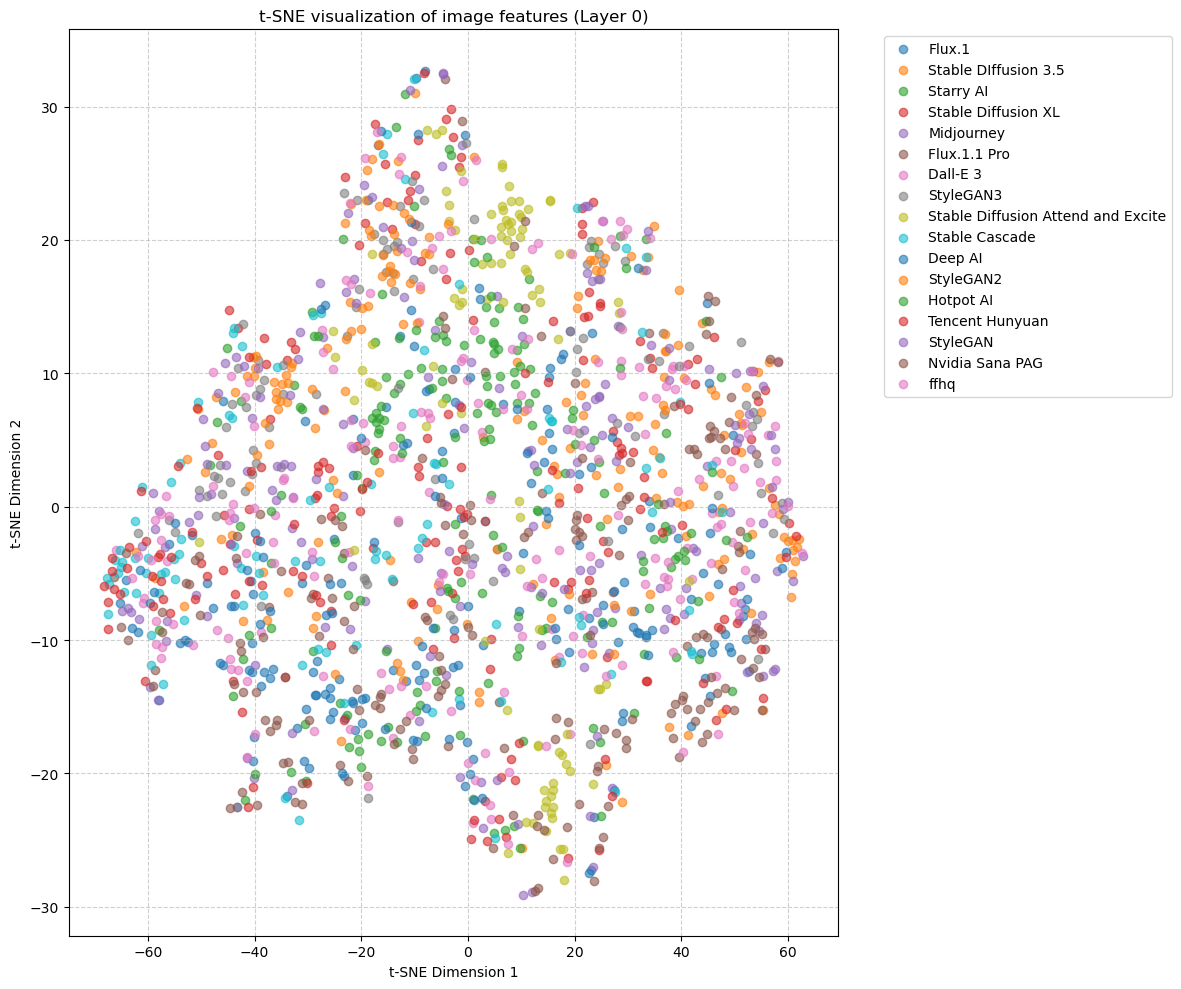

Applying t-SNE for layer 2...
Plotting layer 1...


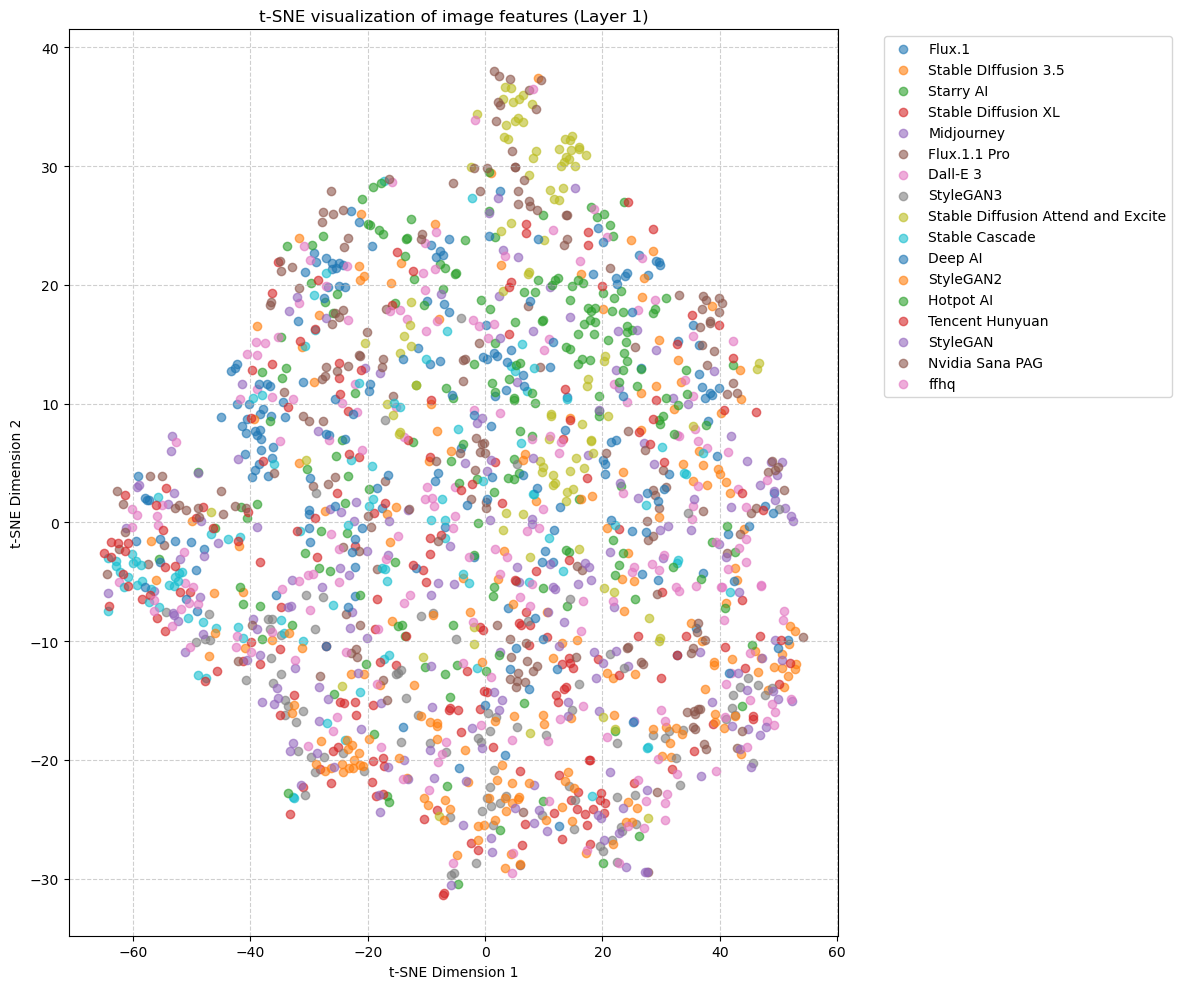

Applying t-SNE for layer 2...
Plotting layer 2...


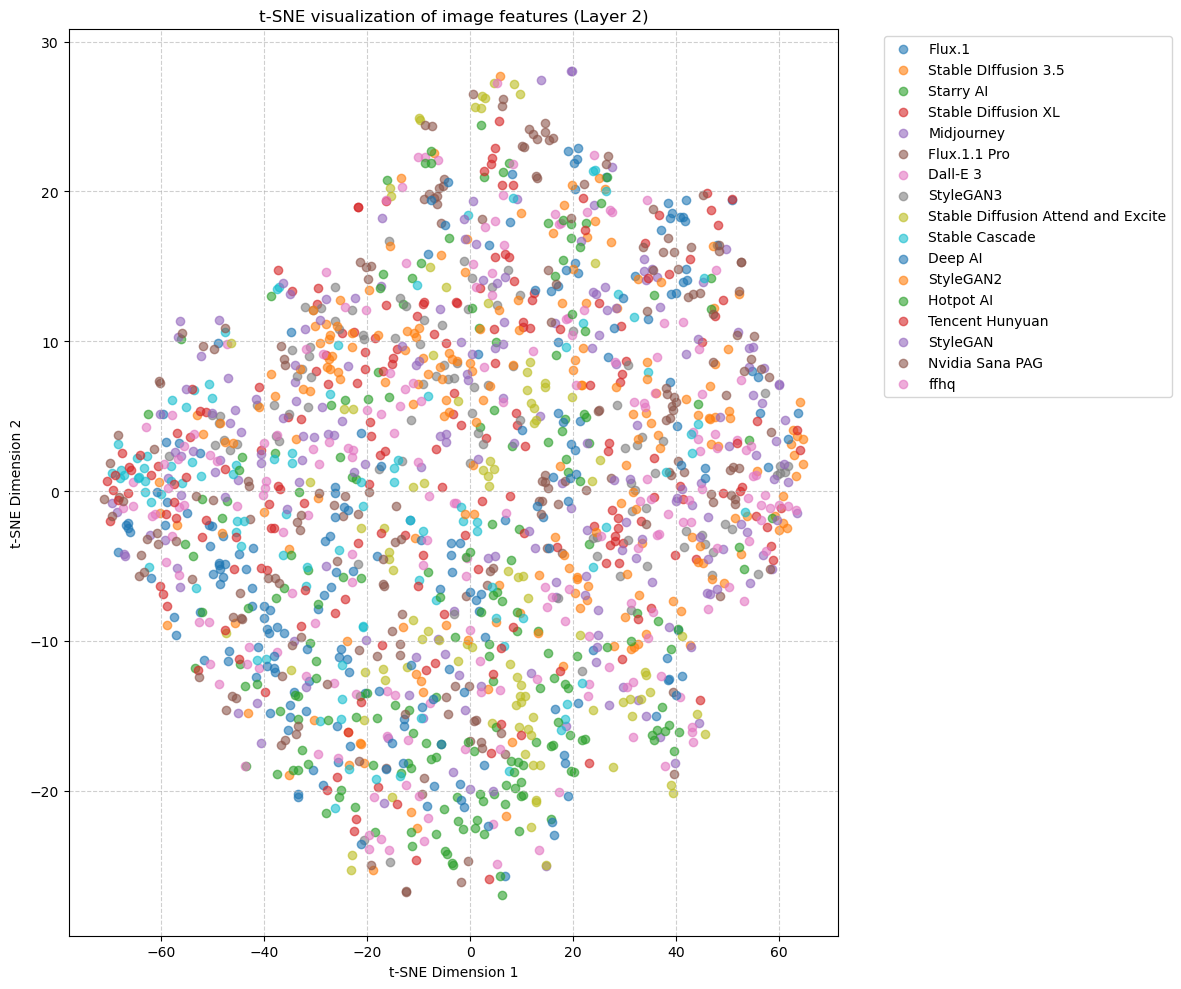

In [16]:
ImageFile.LOAD_TRUNCATED_IMAGES = True

# === Colors for plotting ===
colors = {
    'Leonardo AI': 'lightcoral',
    'Flux.1': 'lightskyblue',
    'ffhq': 'darkblue',                   # strong dark blue
    'Stable DIffusion 3.5': 'lightseagreen',
    'Freepik': 'lightcyan',
    'Starry AI': 'lightpink',
    'StyleGAN3': 'plum',
    'Stable Diffusion XL': 'lightgreen',
    'Stable Diffusion Attend and Excite': 'palegreen',
    'Dall-E': 'lightsteelblue',
    'Midjourney': 'violet',
    'Stable Cascade': 'lightblue',
    'Adobe Firefly': 'lightsalmon',
    'Flux.1.1 Pro': 'khaki',
    'Deep AI': 'lightgoldenrodyellow',
    'StyleGAN2': 'mediumaquamarine',
    # 'celeba_hq': 'darkgoldenrod',         # deep golden-brown
    'Hotpot AI': 'lightcoral',
    'Tencent Hunyuan': 'lightgray',
    'Dall-E 3': 'gainsboro',
    'StyleGAN': 'lightcoral',
    'Nvidia Sana PAG': 'lightyellow'
}

# === Process datasets ===
sample_size = 100
features_by_class = {}   # {label: {layer_idx: [features...]}}
labels = []

for label, pattern in patterns.items():
    files = glob(pattern)
    if not files:
        print(f"[!] No files found for {label}. Skipping.")
        continue
    sample = random.sample(files, min(sample_size, len(files)))
    
    # Prepare storage per layer
    layer_features = {0: [], 1: [], 2: []}

    for img_path in sample:
        try:
            features = get_features_from_path(img_path)
            for i in range(len(features)):
                vec = features[i].mean(dim=(2, 3)).flatten().cpu().numpy()
                layer_features[i].append(vec)
        except Exception as e:
            print(f"Error processing {img_path}: {e}")
            continue

    features_by_class[label] = {
        i: np.array(layer_features[i]) for i in range(len(layer_features))
    }
    labels.extend([label] * len(layer_features[0]))  # all layers have same count

# === Plot each feature layer separately ===
for layer_idx in range(3):  # assuming 3 feature maps
    print(f"Applying t-SNE for layer {2}...")
    
    # Stack features across classes for this layer
    all_features = np.vstack([features_by_class[label][layer_idx] 
                              for label in features_by_class])
    
    tsne = TSNE(n_components=2, random_state=42)
    features_2d = tsne.fit_transform(all_features)
    
    # === Plotting ===
    print(f"Plotting layer {layer_idx}...")
    plt.figure(figsize=(12, 10))
    start = 0

    for label in features_by_class:
        feats = features_by_class[label][layer_idx]
        count = len(feats)
        subset_2d = features_2d[start:start + count]
        plt.scatter(
            subset_2d[:, 0], subset_2d[:, 1],
            label=label,
            alpha=0.6
        )
        start += count

    plt.title(f't-SNE visualization of image features (Layer {layer_idx})')
    plt.xlabel('t-SNE Dimension 1')
    plt.ylabel('t-SNE Dimension 2')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


## Means Analysis

In [51]:
common_path = "/media/orazio_mattia_group/ad4dd/FF4ALL_means/500"
generators = os.listdir(common_path)

patterns_means = {}
for gen in generators:
    patterns_means[gen] = os.path.join(common_path, gen, '*.png')

patterns_means

{'Flux.1': '/media/orazio_mattia_group/ad4dd/FF4ALL_means/500/Flux.1/*.png',
 'ffhq': '/media/orazio_mattia_group/ad4dd/FF4ALL_means/500/ffhq/*.png',
 'Stable DIffusion 3.5': '/media/orazio_mattia_group/ad4dd/FF4ALL_means/500/Stable DIffusion 3.5/*.png',
 'Starry AI': '/media/orazio_mattia_group/ad4dd/FF4ALL_means/500/Starry AI/*.png',
 'StyleGAN3': '/media/orazio_mattia_group/ad4dd/FF4ALL_means/500/StyleGAN3/*.png',
 'Stable Diffusion XL': '/media/orazio_mattia_group/ad4dd/FF4ALL_means/500/Stable Diffusion XL/*.png',
 'Stable Diffusion Attend and Excite': '/media/orazio_mattia_group/ad4dd/FF4ALL_means/500/Stable Diffusion Attend and Excite/*.png',
 'Midjourney': '/media/orazio_mattia_group/ad4dd/FF4ALL_means/500/Midjourney/*.png',
 'Stable Cascade': '/media/orazio_mattia_group/ad4dd/FF4ALL_means/500/Stable Cascade/*.png',
 'Flux.1.1 Pro': '/media/orazio_mattia_group/ad4dd/FF4ALL_means/500/Flux.1.1 Pro/*.png',
 'Deep AI': '/media/orazio_mattia_group/ad4dd/FF4ALL_means/500/Deep AI/*.png

In [55]:
flux_1_means = glob(patterns_means['Flux.1'])
ffhq_means = glob(patterns_means['ffhq'])
stable_diffusion_35_means = glob(patterns_means['Stable DIffusion 3.5'])
starry_ai_means = glob(patterns_means['Starry AI'])
stylegan3_means = glob(patterns_means['StyleGAN3'])
stable_diffusion_xl_means = glob(patterns_means['Stable Diffusion XL'])
attend_and_excite_means = glob(patterns_means['Stable Diffusion Attend and Excite'])
midjourney_means = glob(patterns_means['Midjourney'])
stable_cascade_means = glob(patterns_means['Stable Cascade'])
flux_1_1_pro_means = glob(patterns_means['Flux.1.1 Pro'])
deep_ai_means = glob(patterns_means['Deep AI'])
stylegan2_means = glob(patterns_means['StyleGAN2'])
celeba_hq_means = glob(patterns_means['celeba_hq'])
hotpot_ai_means = glob(patterns_means['Hotpot AI'])
tencent_hunyuan_means = glob(patterns_means['Tencent Hunyuan'])
dalle_3_means = glob(patterns_means['Dall-E 3'])
stylegan_means = glob(patterns_means['StyleGAN'])
nvidia_sana_pag_means = glob(patterns_means['Nvidia Sana PAG'])

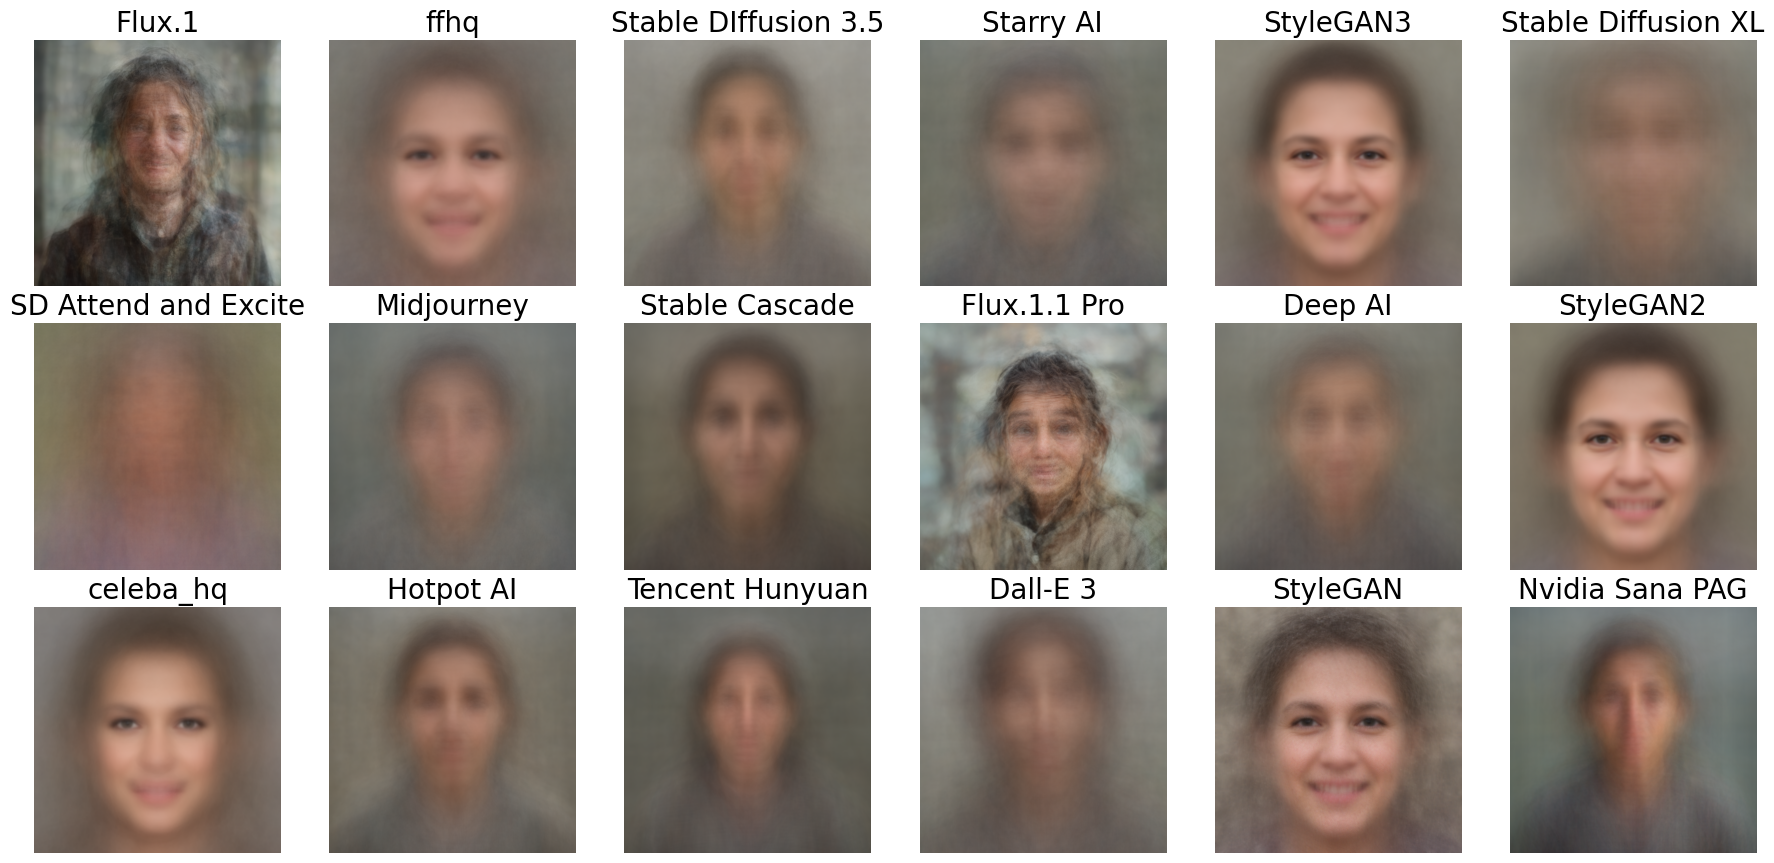

In [56]:
generators_dict = {
    'Flux.1': flux_1_means,
    'ffhq': ffhq_means,
    'Stable DIffusion 3.5': stable_diffusion_35_means,
    'Starry AI': starry_ai_means,
    'StyleGAN3': stylegan3_means,
    'Stable Diffusion XL': stable_diffusion_xl_means,
    'SD Attend and Excite': attend_and_excite_means,
    'Midjourney': midjourney_means,
    'Stable Cascade': stable_cascade_means,
    'Flux.1.1 Pro': flux_1_1_pro_means,
    'Deep AI': deep_ai_means,
    'StyleGAN2': stylegan2_means,
    'celeba_hq': celeba_hq_means,
    'Hotpot AI': hotpot_ai_means,
    'Tencent Hunyuan': tencent_hunyuan_means,
    'Dall-E 3': dalle_3_means,
    'StyleGAN': stylegan_means,
    'Nvidia Sana PAG': nvidia_sana_pag_means
}

# Griglia: calcola righe e colonne in base al numero totale
num_generators = len(generators_dict)
cols = 6
rows = (num_generators + cols - 1) // cols

plt.figure(figsize=(3 * cols, 3 * rows))

for idx, (name, img_list) in enumerate(generators_dict.items()):
    if not img_list:
        continue

    # Seleziona immagine casuale
    img_path = random.choice(img_list)
    try:
        img = Image.open(img_path).convert("RGB")
        img_tensor = torch.from_numpy(np.array(img)).permute(2, 0, 1).float() / 255

        ax = plt.subplot(rows, cols, idx + 1)
        ax.imshow(img_tensor.permute(1, 2, 0))
        ax.set_title(name, fontsize=20)
        ax.axis('off')

    except Exception as e:
        print(f"Errore con immagine {img_path}: {e}")
        continue

plt.tight_layout()
plt.subplots_adjust(top=0.92, hspace=0.15, wspace=0.001)

plt.savefig('/home/mlitrico/ad4dd_means_wceleb.png', dpi=400, bbox_inches='tight')

plt.show()


Applying t-SNE for layer 0...
Plotting layer 0...


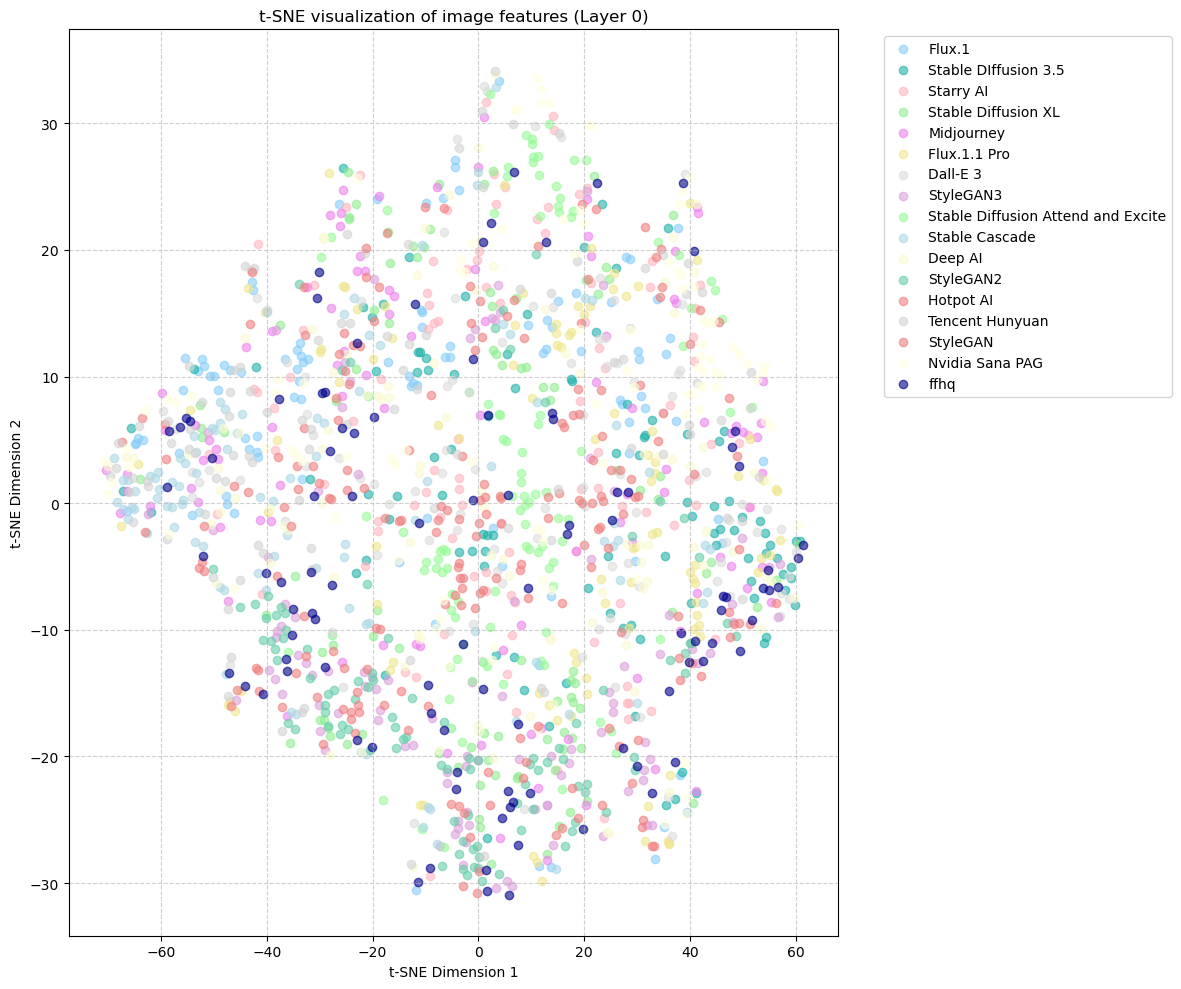

Applying t-SNE for layer 1...
Plotting layer 1...


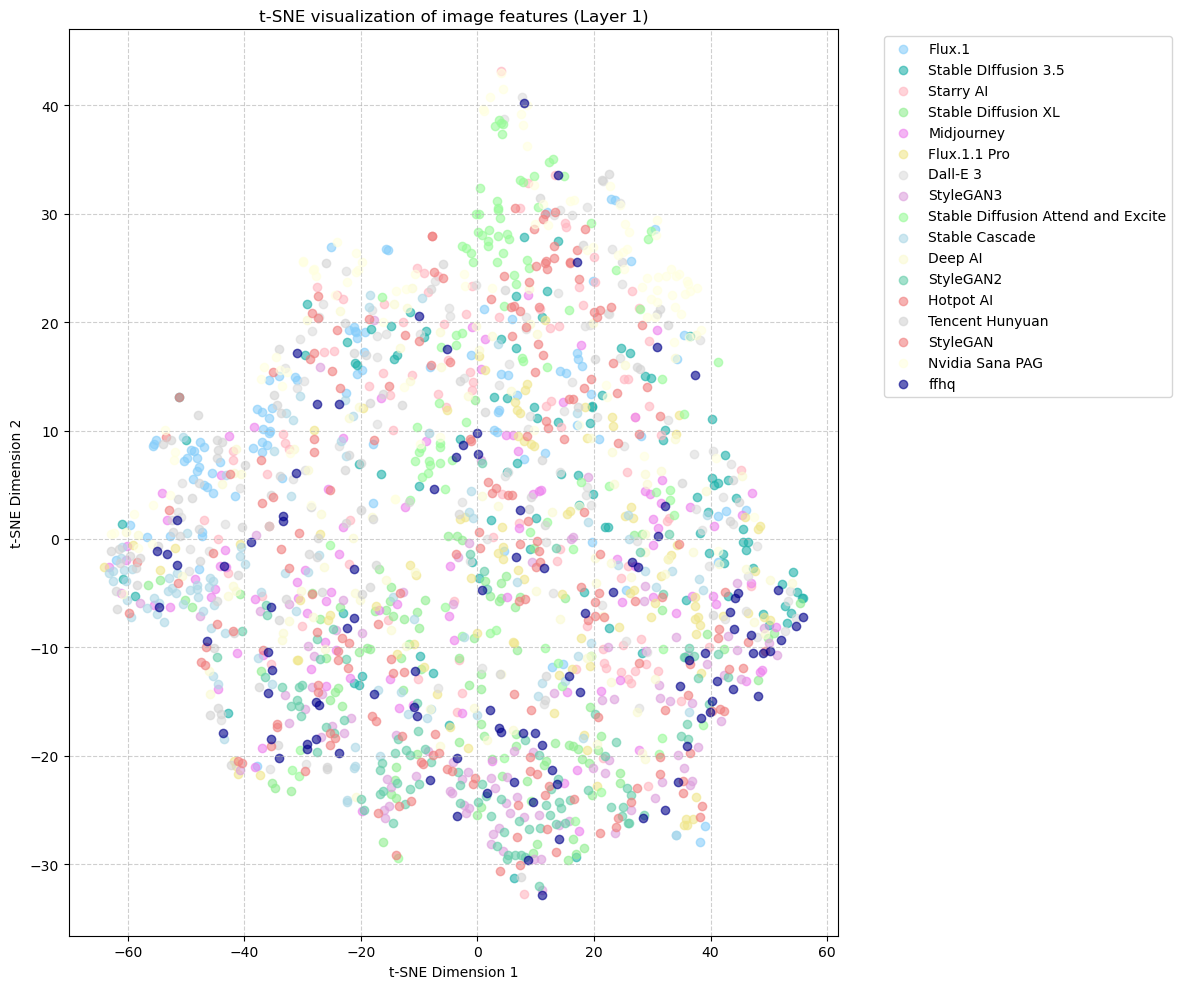

Applying t-SNE for layer 2...
Plotting layer 2...


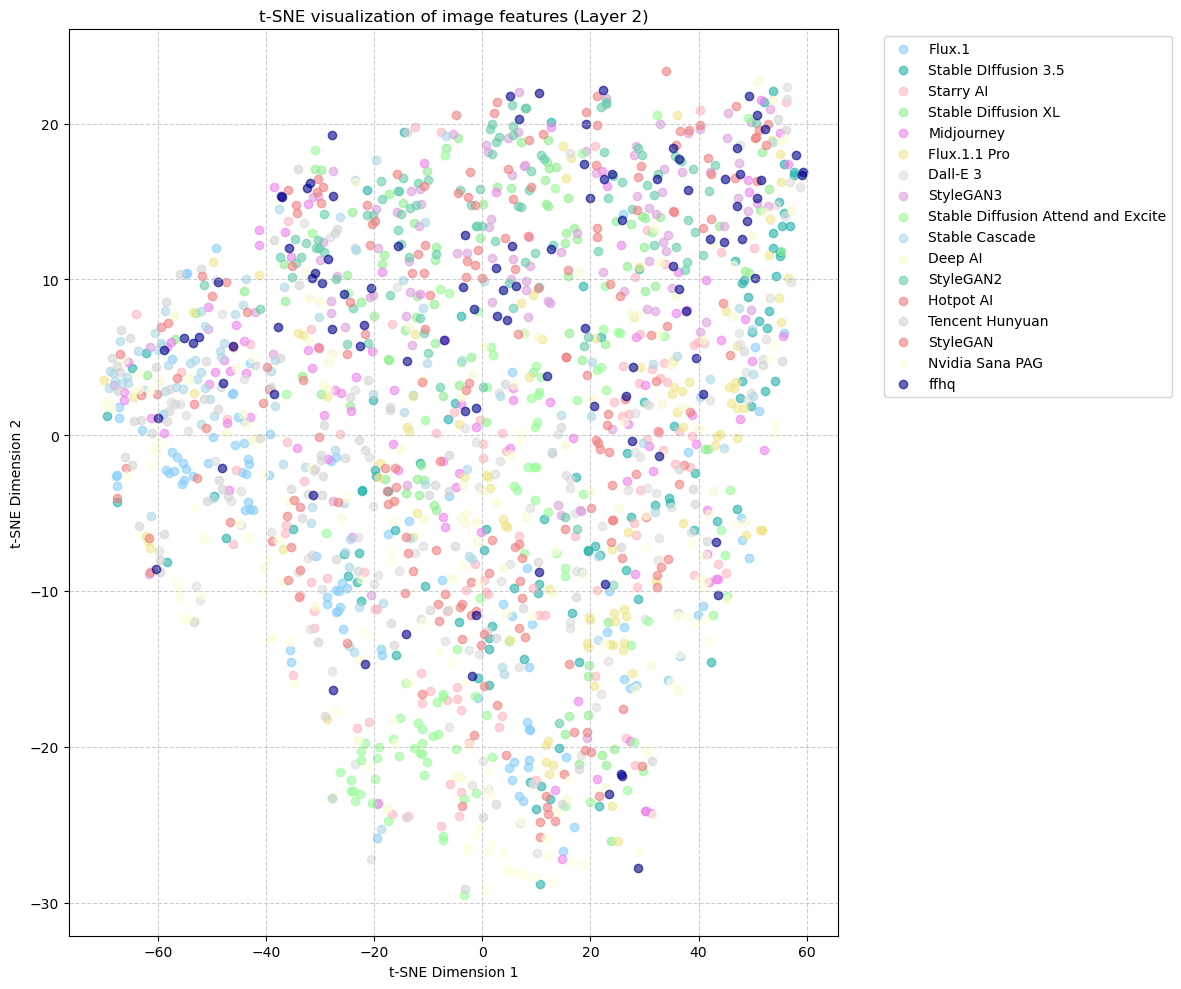

In [ ]:
# === Colors for plotting ===
colors = {
    'Leonardo AI': 'lightcoral',
    'Flux.1': 'lightskyblue',
    'ffhq': 'darkblue',
    'Stable DIffusion 3.5': 'lightseagreen',
    'Freepik': 'lightcyan',
    'Starry AI': 'lightpink',
    'StyleGAN3': 'plum',
    'Stable Diffusion XL': 'lightgreen',
    'Stable Diffusion Attend and Excite': 'palegreen',
    'Dall-E': 'lightsteelblue',
    'Midjourney': 'violet',
    'Stable Cascade': 'lightblue',
    'Adobe Firefly': 'lightsalmon',
    'Flux.1.1 Pro': 'khaki',
    'Deep AI': 'lightgoldenrodyellow',
    'StyleGAN2': 'mediumaquamarine',
    # 'celeba_hq': 'darkgoldenrod',
    'Hotpot AI': 'lightcoral',
    'Tencent Hunyuan': 'lightgray',
    'Dall-E 3': 'gainsboro',
    'StyleGAN': 'lightcoral',
    'Nvidia Sana PAG': 'lightyellow'
}

# === Process datasets ===
sample_size = 100
features_by_class = {}   # {label: {layer_idx: [features...]}}
labels = []

for label, pattern in patterns.items():
    files = glob(pattern)
    if not files:
        print(f"[!] No files found for {label}. Skipping.")
        continue
    sample = random.sample(files, min(sample_size, len(files)))

    # Prepare per-layer containers
    layer_features = {}

    for img_path in sample:
        try:
            features = get_features_from_path(img_path)
            for i in range(len(features)):
                vec = features[i].mean(dim=(2, 3)).flatten().cpu().numpy()
                layer_features.setdefault(i, []).append(vec)
        except Exception as e:
            print(f"Error processing {img_path}: {e}")
            continue

    features_by_class[label] = {
        i: np.array(layer_features[i]) for i in layer_features
    }
    labels.extend([label] * len(next(iter(layer_features.values()))))

# === Run t-SNE + Plot separately for each layer ===
num_layers = len(next(iter(features_by_class.values())))
for layer_idx in range(num_layers):
    print(f"Applying t-SNE for layer {layer_idx}...")
    all_features = np.vstack([features_by_class[label][layer_idx]
                              for label in features_by_class])
    
    tsne = TSNE(n_components=2, random_state=42)
    features_2d = tsne.fit_transform(all_features)

    print(f"Plotting layer {layer_idx}...")
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111)
    start = 0

    for label in features_by_class:
        feats = features_by_class[label][layer_idx]
        count = len(feats)
        subset_2d = features_2d[start:start + count]
        ax.scatter(
            subset_2d[:, 0], subset_2d[:, 1],
            label=label,
            c=colors.get(label, 'gray'),
            alpha=0.6
        )
        start += count

    plt.title(f't-SNE visualization of image features (Layer {layer_idx})')
    plt.xlabel('t-SNE Dimension 1')
    plt.ylabel('t-SNE Dimension 2')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


### Get GMM parameters

In [21]:
reals = 'ffhq'
assert reals in ['ffhq', 'celeba_hq', 'ffhq+celeba_hq']


if reals == 'ffhq':
    real_sample = ffhq_means
elif reals == 'celeba_hq':
    real_sample = celeba_hq_means
else:
    real_sample = ffhq_means+celeba_hq_means
print(f"Number of real samples: {len(real_sample)}")
print("Extracting features...")
real_features = []
for img_path in real_sample:
    features = get_features_from_path(img_path)
    feats_ = []
    for feats in features:
        feats_.append(feats.mean([2, 3]).flatten().cpu().numpy())
    real_features.append(feats_)
    
gmm = {"real": []}

clf = GaussianMixture()
for i in range(len(real_features[0])):
    real_features_ = np.stack([feats[i] for feats in real_features])
    print(real_features_.shape)
    
    clf.fit(real_features_)
    gmm["real"].append([clf.means_, clf.covariances_])

np.save(f"parameters/gmm_parameters_{model_name}_{reals}_{config['input_size']}_new.npy", gmm)

Number of real samples: 1000
Extracting features...
(1000, 64)
(1000, 128)
(1000, 256)


# Paper Imges

In [7]:
ImageFile.LOAD_TRUNCATED_IMAGES = True

# === Colors for plotting ===
colors = {
    'Leonardo AI': '#1f77b4',   # blu
    'Flux.1': '#ff7f0e',        # arancione
    'ffhq': '#2ca02c',          # verde
    'Stable DIffusion 3.5': '#d62728',  # rosso
    'Freepik': '#9467bd',       # viola
    'Starry AI': '#8c564b',     # marrone
    'StyleGAN3': '#e377c2',     # rosa
    'Stable Diffusion XL': '#7f7f7f',   # grigio
    'Stable Diffusion Attend and Excite': '#bcbd22',  # giallo-verde
    'Dall-E': '#17becf',        # ciano
    'Midjourney': '#aec7e8',    # azzurro chiaro
    'Stable Cascade': '#ffbb78',# arancio chiaro
    'Adobe Firefly': '#98df8a', # verde chiaro
    'Flux.1.1 Pro': '#ff9896',  # rosato
    'Deep AI': '#c5b0d5',       # lavanda
    'StyleGAN2': '#c49c94',     # beige
    'Hotpot AI': '#f7b6d2',     # rosa tenue
    'Tencent Hunyuan': '#dbdb8d', # giallo tenue
    'Dall-E 3': '#9edae5',      # azzurro pallido
    'StyleGAN': '#393b79',      # blu scuro
    'Nvidia Sana PAG': '#637939' # verde oliva
}


# === Process first dataset (patterns) ===
sample_size = 100
features_by_class_1 = {}
labels_1 = []

for label, pattern in patterns.items():
    files = glob(pattern)
    if not files:
        print(f"[!] No files found for {label}. Skipping.")
        continue
    sample = random.sample(files, min(sample_size, len(files)))
    
    layer_features = {0: [], 1: [], 2: []}

    for img_path in sample:
        try:
            features = get_features_from_path(img_path)
            for i in range(len(features)):
                vec = features[i].mean(dim=(2, 3)).flatten().cpu().numpy()
                layer_features[i].append(vec)
        except Exception as e:
            print(f"Error processing {img_path}: {e}")
            continue

    features_by_class_1[label] = {
        i: np.array(layer_features[i]) for i in range(len(layer_features))
    }
    labels_1.extend([label] * len(layer_features[0]))

# === Process second dataset (patterns_means) ===
features_by_class_2 = {}
labels_2 = []

for label, pattern in patterns_means.items():
    files = glob(pattern)
    if not files:
        print(f"[!] No files found for {label}. Skipping.")
        continue
    sample = random.sample(files, min(sample_size, len(files)))

    layer_features = {}

    for img_path in sample:
        try:
            features = get_features_from_path(img_path)
            for i in range(len(features)):
                vec = features[i].mean(dim=(2, 3)).flatten().cpu().numpy()
                layer_features.setdefault(i, []).append(vec)
        except Exception as e:
            print(f"Error processing {img_path}: {e}")
            continue

    features_by_class_2[label] = {
        i: np.array(layer_features[i]) for i in layer_features
    }
    labels_2.extend([label] * len(next(iter(layer_features.values()))))


all_features_1 = np.vstack([features_by_class_1[label][2] 
                            for label in features_by_class_1])

tsne_1 = TSNE(n_components=2, random_state=42)
features_2d_1 = tsne_1.fit_transform(all_features_1)

all_features_2 = np.vstack([features_by_class_2[label][2]
                            for label in features_by_class_2])

tsne_2 = TSNE(n_components=2, random_state=42)
features_2d_2 = tsne_2.fit_transform(all_features_2)
    


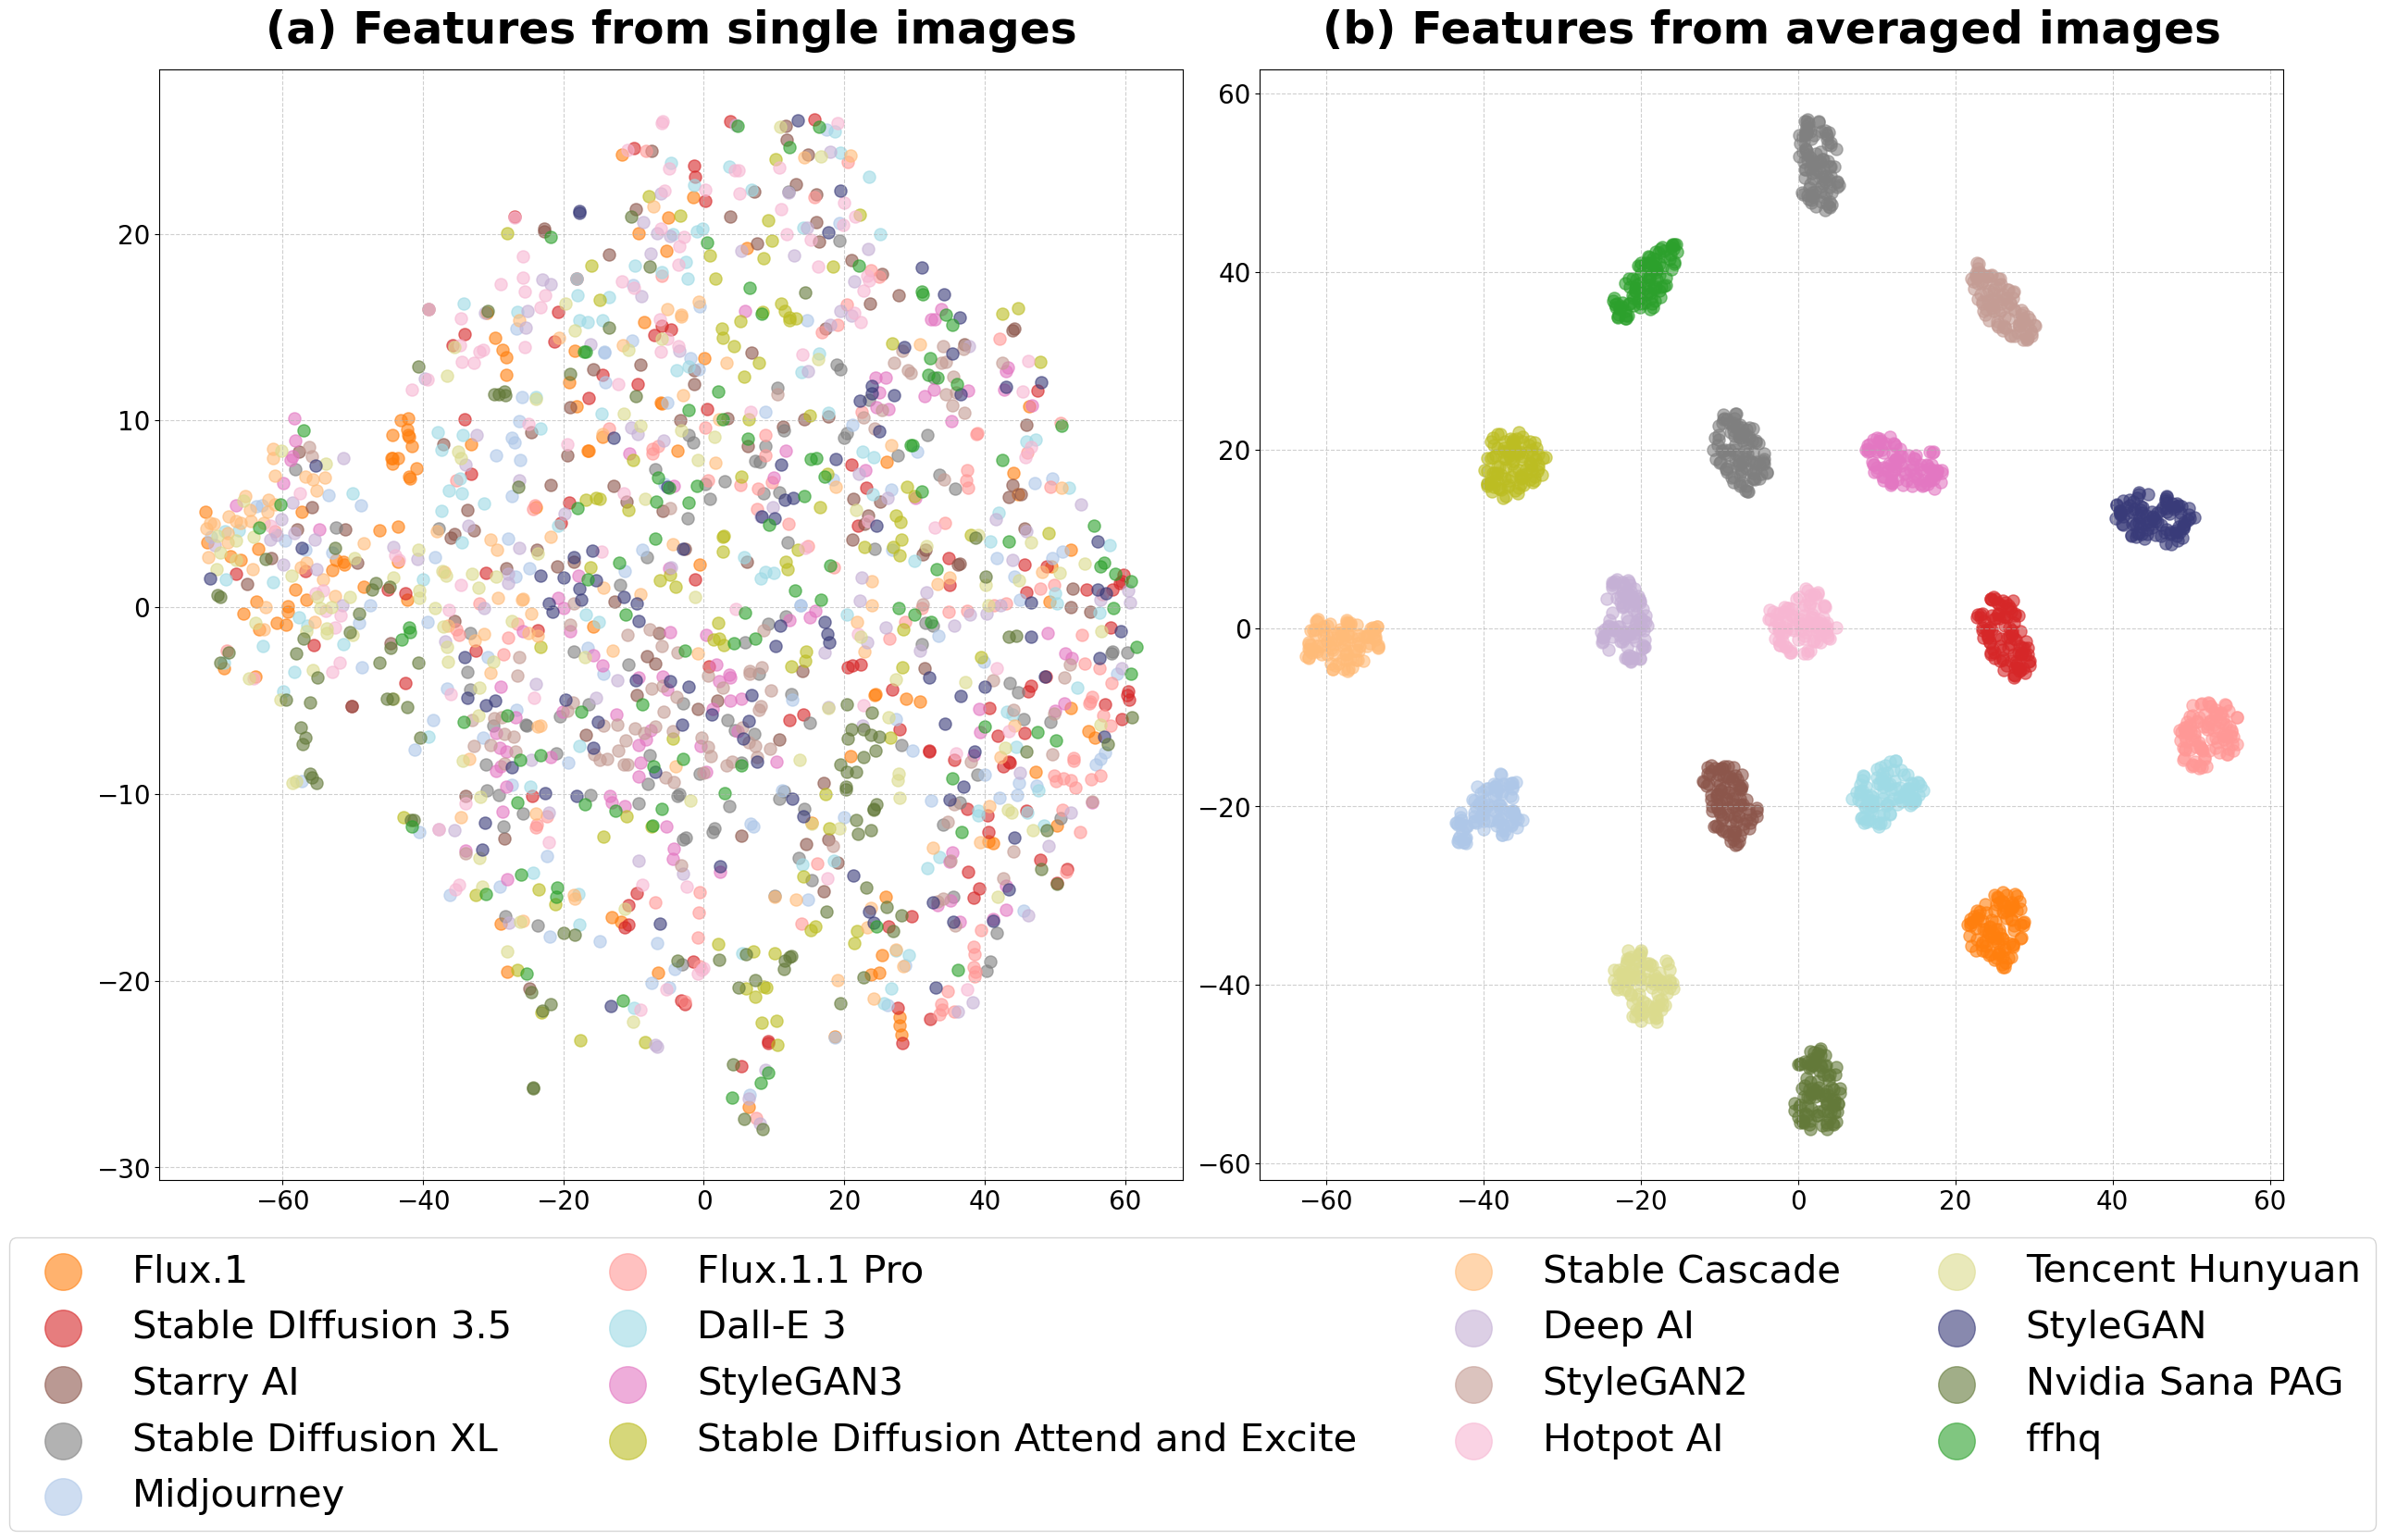

In [17]:
# === Create figure with two subplots side by side ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 16))

# === First plot (left) - patterns ===


start = 0
for label in features_by_class_1:
    feats = features_by_class_1[label][2]
    count = len(feats)
    subset_2d = features_2d_1[start:start + count]
    ax1.scatter(
        subset_2d[:, 0], subset_2d[:, 1],
        label=label,
        c=colors.get(label, 'gray'),
        alpha=0.6,
        s=90
    )
    start += count

ax1.set_title('(a) Features from single images', fontsize=35, fontweight='bold', pad=20)
#ax1.set_xlabel('t-SNE Dimension 1', fontsize=18)
#ax1.set_ylabel('t-SNE Dimension 2', fontsize=18)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.tick_params(axis='both', which='major', labelsize=20)
#ax1.set_xticks([])
#ax1.set_yticks([])

# === Second plot (right) - patterns_means ===

start = 0
for label in features_by_class_2:
    feats = features_by_class_2[label][2]
    count = len(feats)
    subset_2d = features_2d_2[start:start + count]
    ax2.scatter(
        subset_2d[:, 0], subset_2d[:, 1],
        label=label,
        c=colors.get(label, 'gray'),
        alpha=0.6,
        s=90
    )
    start += count

ax2.set_title('(b) Features from averaged images', fontsize=35, fontweight='bold', pad=20)
#ax2.set_xlabel('t-SNE Dimension 1', fontsize=18)
#ax2.set_ylabel('t-SNE Dimension 2', fontsize=18)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.tick_params(axis='both', which='major', labelsize=20)
#ax2.set_xticks([])
#ax2.set_yticks([])

# === Common legend below both plots ===
handles, labels_legend = ax1.get_legend_handles_labels()
fig.legend(handles, labels_legend, loc='lower center', ncol=4, 
           bbox_to_anchor=(0.5, -0.05), frameon=True, fontsize=30, markerscale=3)

plt.tight_layout()
plt.subplots_adjust(bottom=0.20)

plt.savefig('/home/mlitrico/features_1.png', dpi=400, bbox_inches='tight')
plt.show()

In [7]:
# ============================================================================
# PARTE 1: COMPUTAZIONE E SALVATAGGIO DATI
# ============================================================================

import os
from glob import glob
import random
import numpy as np
import pickle
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics.cluster import adjusted_rand_score
from PIL import ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True

# Valori di k da iterare
k_values = [50, 100, 200, 300, 400, 500, 600, 700]

sample_size = 100

# Storage per le metriche
clustering_metrics = {
    'Silhouette Score': [],
    'Calinski-Harabasz Index': [],
    'Davies-Bouldin Index': [],
    'Adjusted Rand Index': []
}

# Storage per i plot t-SNE
tsne_plots_data = []

# Iterazione su tutti i valori di k
for k in k_values:
    print(f"\n{'='*60}")
    print(f"Processing k = {k}")
    print(f"{'='*60}\n")
    
    common_path = f"/media/orazio_mattia_group/ad4dd/FF4ALL_means/{k}"
    
    if not os.path.exists(common_path):
        print(f"[!] Path not found for k={k}: {common_path}. Skipping.")
        continue
    
    generators = os.listdir(common_path)
    patterns_means = {}
    
    for gen in generators:
        patterns_means[gen] = os.path.join(common_path, gen, '*.png')
    
    # Costruzione del dizionario patterns per ogni generatore
    patterns = {}
    
    if 'Flux.1' in patterns_means:
        patterns['Flux.1'] = patterns_means['Flux.1']
    if 'ffhq' in patterns_means:
        patterns['ffhq'] = patterns_means['ffhq']
    if 'Stable DIffusion 3.5' in patterns_means:
        patterns['Stable DIffusion 3.5'] = patterns_means['Stable DIffusion 3.5']
    if 'Starry AI' in patterns_means:
        patterns['Starry AI'] = patterns_means['Starry AI']
    if 'StyleGAN3' in patterns_means:
        patterns['StyleGAN3'] = patterns_means['StyleGAN3']
    if 'Stable Diffusion XL' in patterns_means:
        patterns['Stable Diffusion XL'] = patterns_means['Stable Diffusion XL']
    if 'Stable Diffusion Attend and Excite' in patterns_means:
        patterns['Stable Diffusion Attend and Excite'] = patterns_means['Stable Diffusion Attend and Excite']
    if 'Midjourney' in patterns_means:
        patterns['Midjourney'] = patterns_means['Midjourney']
    if 'Stable Cascade' in patterns_means:
        patterns['Stable Cascade'] = patterns_means['Stable Cascade']
    if 'Flux.1.1 Pro' in patterns_means:
        patterns['Flux.1.1 Pro'] = patterns_means['Flux.1.1 Pro']
    if 'Deep AI' in patterns_means:
        patterns['Deep AI'] = patterns_means['Deep AI']
    if 'StyleGAN2' in patterns_means:
        patterns['StyleGAN2'] = patterns_means['StyleGAN2']
    if 'celeba_hq' in patterns_means:
        patterns['celeba_hq'] = patterns_means['celeba_hq']
    if 'Hotpot AI' in patterns_means:
        patterns['Hotpot AI'] = patterns_means['Hotpot AI']
    if 'Tencent Hunyuan' in patterns_means:
        patterns['Tencent Hunyuan'] = patterns_means['Tencent Hunyuan']
    if 'Dall-E 3' in patterns_means:
        patterns['Dall-E 3'] = patterns_means['Dall-E 3']
    if 'StyleGAN' in patterns_means:
        patterns['StyleGAN'] = patterns_means['StyleGAN']
    if 'Nvidia Sana PAG' in patterns_means:
        patterns['Nvidia Sana PAG'] = patterns_means['Nvidia Sana PAG']
    
    # === Process datasets ===
    features_by_class = {}
    labels = []
    label_indices = []
    
    for label_idx, (label, pattern) in enumerate(patterns.items()):
        files = glob(pattern)
        if not files:
            print(f"[!] No files found for {label}. Skipping.")
            continue
        sample = random.sample(files, min(sample_size, len(files)))
        print(f"Sample size for {label}: {len(sample)}")
        
        # Prepare per-layer containers
        layer_features = {}
        
        for img_path in sample:
            try:
                features = get_features_from_path(img_path)
                for i in range(len(features)):
                    vec = features[i].mean(dim=(2, 3)).flatten().cpu().numpy()
                    layer_features.setdefault(i, []).append(vec)
            except Exception as e:
                print(f"Error processing {img_path}: {e}")
                continue
        
        features_by_class[label] = {
            i: np.array(layer_features[i]) for i in layer_features
        }
        labels.extend([label] * len(next(iter(layer_features.values()))))
        label_indices.extend([label_idx] * len(next(iter(layer_features.values()))))
    
    if not features_by_class:
        print(f"[!] No features extracted for k={k}. Skipping visualization.")
        continue
    
    # === Combine features and run t-SNE ===
    all_features = np.vstack([features_by_class[label][2]
                                for label in features_by_class])
    label_indices = np.array(label_indices)
    
    print("Running t-SNE...")
    tsne = TSNE(n_components=2, random_state=42)
    features_2d = tsne.fit_transform(all_features)
    
    # Store data per il plot
    tsne_plots_data.append({
        'k': k,
        'features_2d': features_2d,
        'labels': labels,
        'features_by_class': features_by_class,
        'all_features': all_features,
        'label_indices': label_indices
    })
    
    # === Calcola metriche di clustering ===
    print("Computing clustering metrics...")
    
    # Silhouette Score (range: -1 to 1, higher is better)
    silhouette = silhouette_score(all_features, label_indices)
    clustering_metrics['Silhouette Score'].append(silhouette)
    
    # Calinski-Harabasz Index (higher is better)
    calinski = calinski_harabasz_score(all_features, label_indices)
    clustering_metrics['Calinski-Harabasz Index'].append(calinski)
    
    # Davies-Bouldin Index (lower is better)
    davies = davies_bouldin_score(all_features, label_indices)
    clustering_metrics['Davies-Bouldin Index'].append(davies)
    
    # Adjusted Rand Index (range: -1 to 1, 1 is perfect)
    # Per ARI usiamo una baseline random
    n_samples = len(label_indices)
    random_labels = np.random.randint(0, len(patterns), n_samples)
    ari = adjusted_rand_score(label_indices, random_labels)
    clustering_metrics['Adjusted Rand Index'].append(ari)
    
    print(f"Silhouette Score: {silhouette:.4f}")
    print(f"Calinski-Harabasz Index: {calinski:.4f}")
    print(f"Davies-Bouldin Index: {davies:.4f}")
    print(f"Adjusted Rand Index: {ari:.4f}")

# === Salva tutti i dati computati ===
print("\n" + "="*60)
print("Saving computed data...")
print("="*60)

data_to_save = {
    'k_values': k_values,
    'tsne_plots_data': tsne_plots_data,
    'clustering_metrics': clustering_metrics
}

with open('computed_data.pkl', 'wb') as f:
    pickle.dump(data_to_save, f)

print("Data saved to 'computed_data.pkl'")
print("="*60)


Processing k = 50

Sample size for Flux.1: 100
Sample size for ffhq: 100
Sample size for Stable DIffusion 3.5: 100
Sample size for Starry AI: 100
Sample size for StyleGAN3: 100
Sample size for Stable Diffusion XL: 100
Sample size for Stable Diffusion Attend and Excite: 100
Sample size for Midjourney: 100
Sample size for Stable Cascade: 100
Sample size for Flux.1.1 Pro: 100
Sample size for Deep AI: 100
Sample size for StyleGAN2: 100
Sample size for celeba_hq: 100
Sample size for Hotpot AI: 100
Sample size for Tencent Hunyuan: 100
Sample size for Dall-E 3: 100
Sample size for StyleGAN: 100
Sample size for Nvidia Sana PAG: 100
Running t-SNE...
Computing clustering metrics...
Silhouette Score: 0.2514
Calinski-Harabasz Index: 712.0176
Davies-Bouldin Index: 1.6881
Adjusted Rand Index: -0.0004

Processing k = 100

Sample size for Flux.1: 100
Sample size for ffhq: 100
Sample size for Stable DIffusion 3.5: 100
Sample size for Starry AI: 100
Sample size for StyleGAN3: 100
Sample size for Stable


Loading computed data...
Loaded data for 8 K values
Creating t-SNE grid plot...
Saved grid plot: tsne_grid_all_k.png


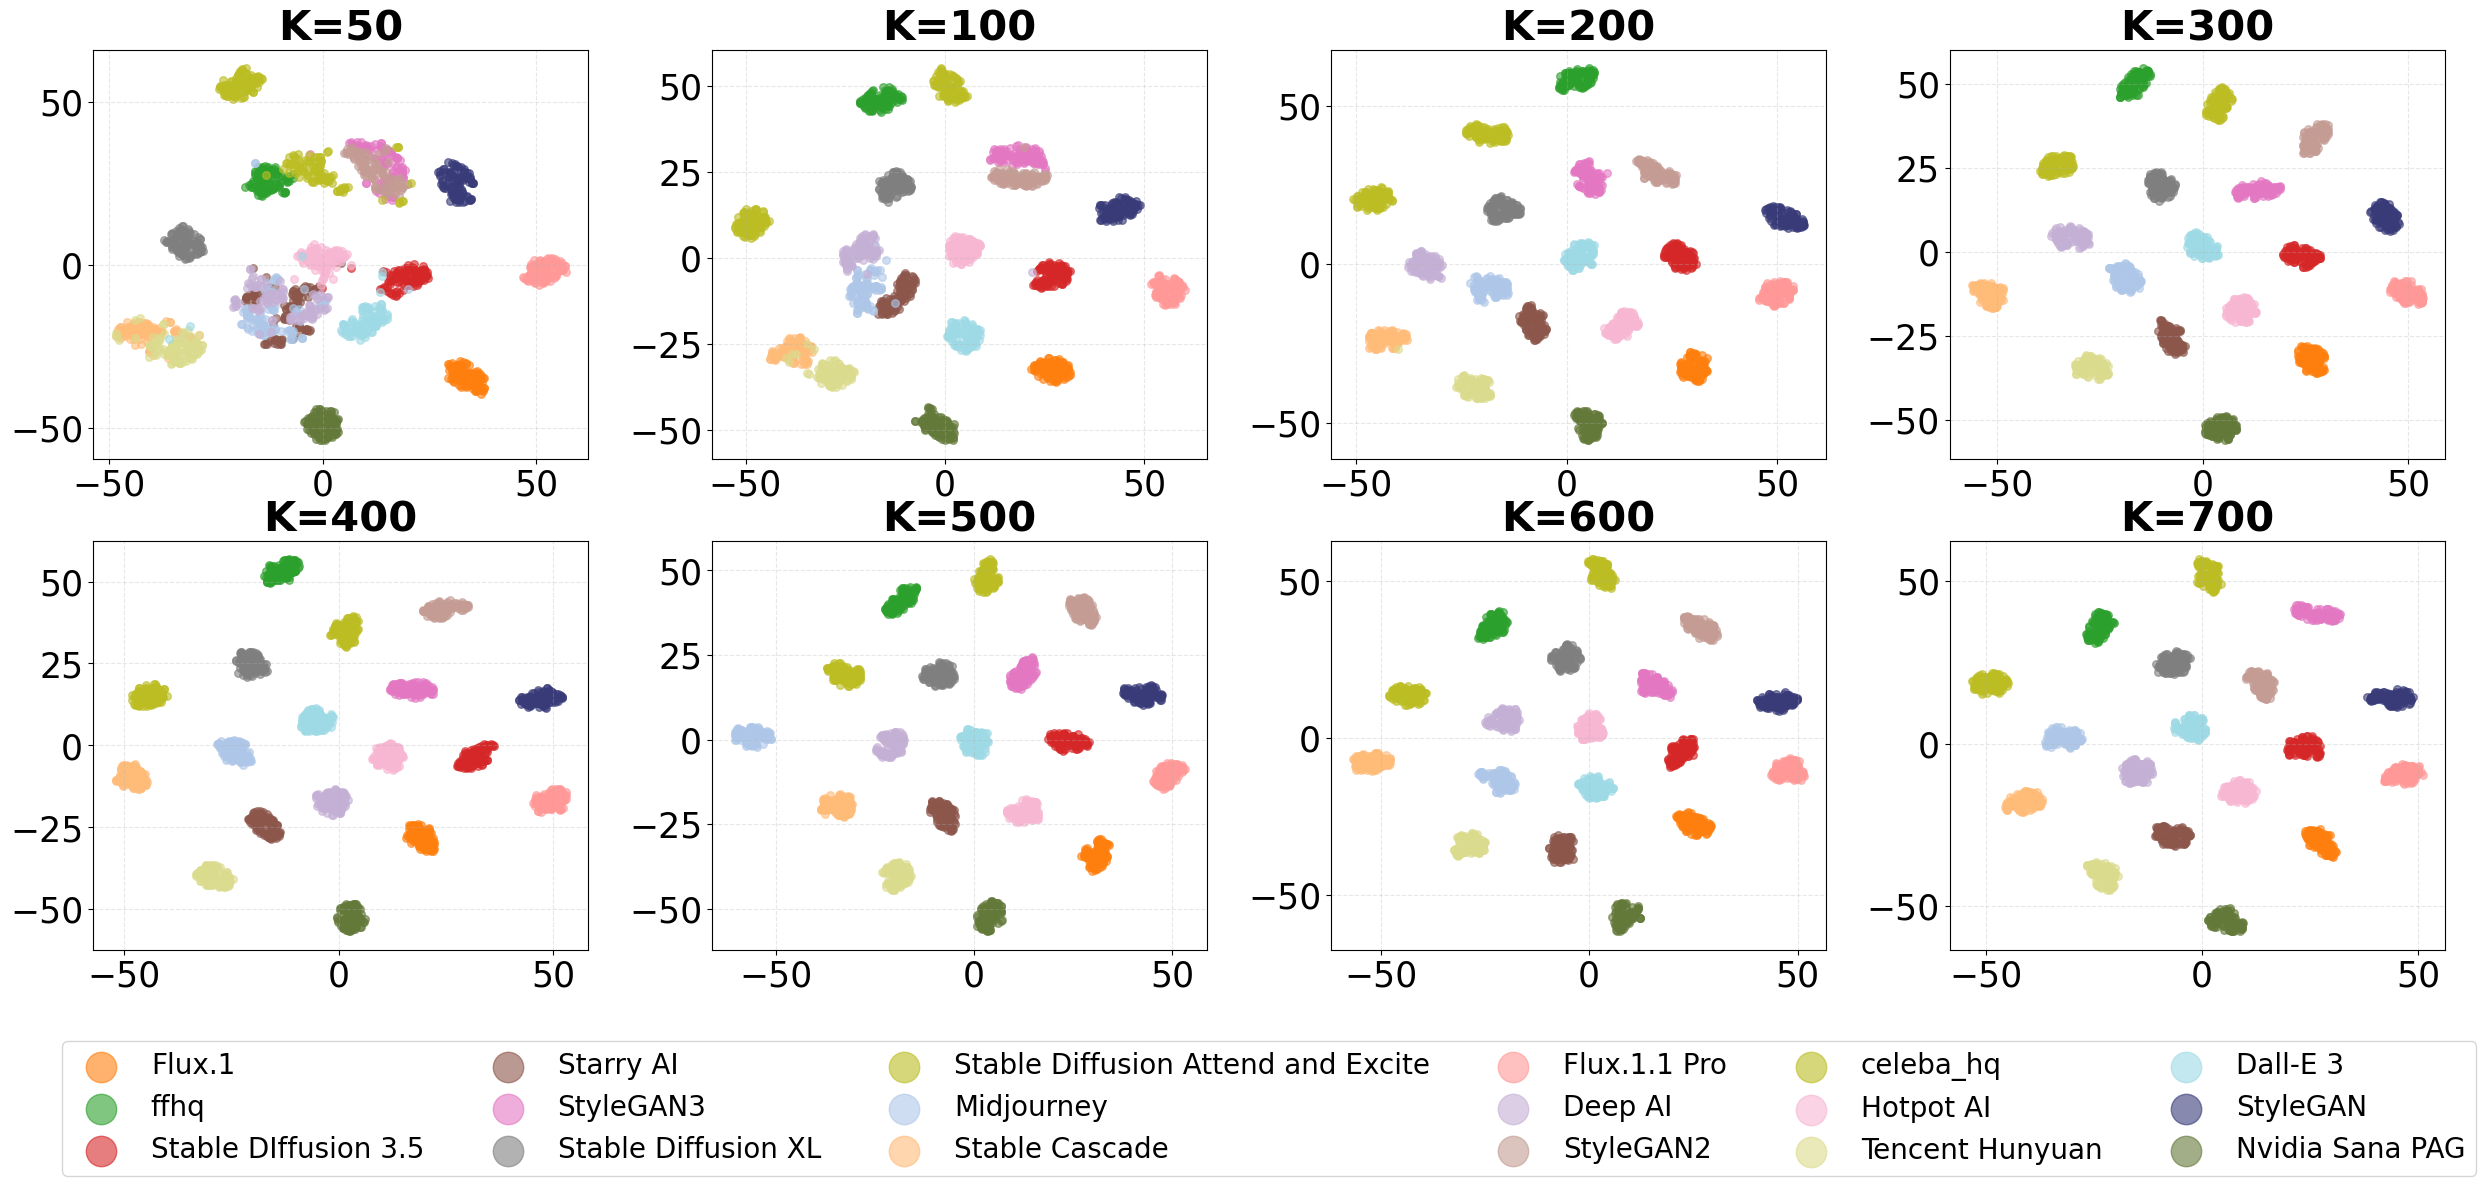

Creating clustering metrics plot...
Saved metrics plot: clustering_metrics.png


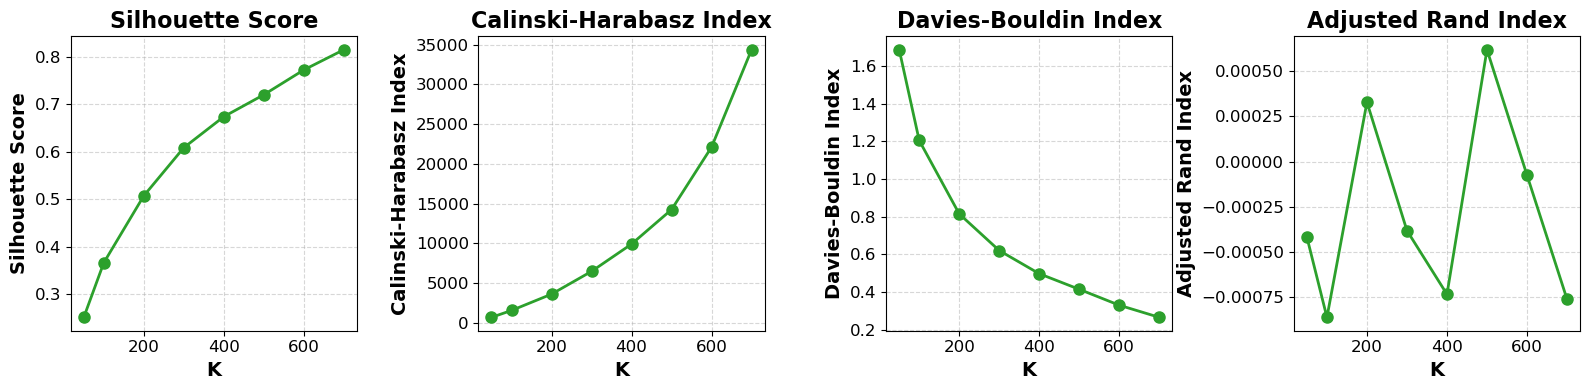


Plotting completed!


In [2]:
# ============================================================================
# PARTE 2: CARICAMENTO DATI E PLOTTING
# ============================================================================

import pickle
import numpy as np
import matplotlib.pyplot as plt

# === Colors for plotting ===
colors = {
    'Leonardo AI': '#1f77b4',
    'Flux.1': '#ff7f0e',
    'ffhq': '#2ca02c',
    'Stable DIffusion 3.5': '#d62728',
    'Freepik': '#9467bd',
    'Starry AI': '#8c564b',
    'StyleGAN3': '#e377c2',
    'Stable Diffusion XL': '#7f7f7f',
    'Stable Diffusion Attend and Excite': '#bcbd22',
    'Dall-E': '#17becf',
    'Midjourney': '#aec7e8',
    'Stable Cascade': '#ffbb78',
    'Adobe Firefly': '#98df8a',
    'Flux.1.1 Pro': '#ff9896',
    'Deep AI': '#c5b0d5',
    'StyleGAN2': '#c49c94',
    'Hotpot AI': '#f7b6d2',
    'Tencent Hunyuan': '#dbdb8d',
    'Dall-E 3': '#9edae5',
    'StyleGAN': '#393b79',
    'Nvidia Sana PAG': '#637939',
    'celeba_hq': '#bcbd22'
}

print("\n" + "="*60)
print("Loading computed data...")
print("="*60)

# Carica i dati
with open('computed_data.pkl', 'rb') as f:
    data = pickle.load(f)

k_values = data['k_values']
tsne_plots_data = data['tsne_plots_data']
clustering_metrics = data['clustering_metrics']

print(f"Loaded data for {len(tsne_plots_data)} K values")

# === Crea griglia 4x2 dei plot t-SNE (2 righe x 4 colonne) ===
print("Creating t-SNE grid plot...")

fig = plt.figure(figsize=(24, 12))
gs = fig.add_gridspec(2, 4, hspace=0.2, wspace=0.25, bottom=0.2, top=0.95, left=0.01, right=0.99)

for idx, plot_data in enumerate(tsne_plots_data):
    row = idx // 4
    col = idx % 4
    ax = fig.add_subplot(gs[row, col])
    
    features_2d = plot_data['features_2d']
    features_by_class = plot_data['features_by_class']
    k = plot_data['k']
    
    start = 0
    for label in features_by_class:
        feats = features_by_class[label][2]
        count = len(feats)
        subset_2d = features_2d[start:start + count]
        ax.scatter(
            subset_2d[:, 0], subset_2d[:, 1],
            label=label,
            c=colors.get(label, 'gray'),
            alpha=0.6,
            s=30
        )
        start += count
    
    ax.set_title(f'K={k}', fontsize=30, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.tick_params(axis='both', which='major', labelsize=25)

# Leggenda unica centrata in basso
handles, labels_legend = ax.get_legend_handles_labels()
fig.legend(handles, labels_legend, loc='lower center', ncol=6, 
           bbox_to_anchor=(0.5, 0.0), frameon=True, fontsize=20, markerscale=4)

plt.savefig('tsne_grid_all_k.png', dpi=400, bbox_inches='tight')
print("Saved grid plot: tsne_grid_all_k.png")
plt.show()
plt.close()

# === Crea plot delle metriche di clustering ===
print("Creating clustering metrics plot...")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes = axes.flatten()

metric_names = list(clustering_metrics.keys())
for idx, metric_name in enumerate(metric_names):
    ax = axes[idx]
    metric_values = clustering_metrics[metric_name]
    k_vals = k_values[:len(metric_values)]
    
    ax.plot(k_vals, metric_values, 
            marker='o', linewidth=2, markersize=8, color='#2ca02c')
    ax.set_xlabel('K', fontsize=14, fontweight='bold')
    ax.set_ylabel(metric_name, fontsize=14, fontweight='bold')
    ax.set_title(metric_name, fontsize=16, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.tick_params(axis='both', which='major', labelsize=12)

plt.tight_layout()
plt.savefig('clustering_metrics.png', dpi=400, bbox_inches='tight')
print("Saved metrics plot: clustering_metrics.png")
plt.show()
plt.close()

print("\n" + "="*60)
print("Plotting completed!")
print("="*60)

Saved metrics plot: silhouette.png


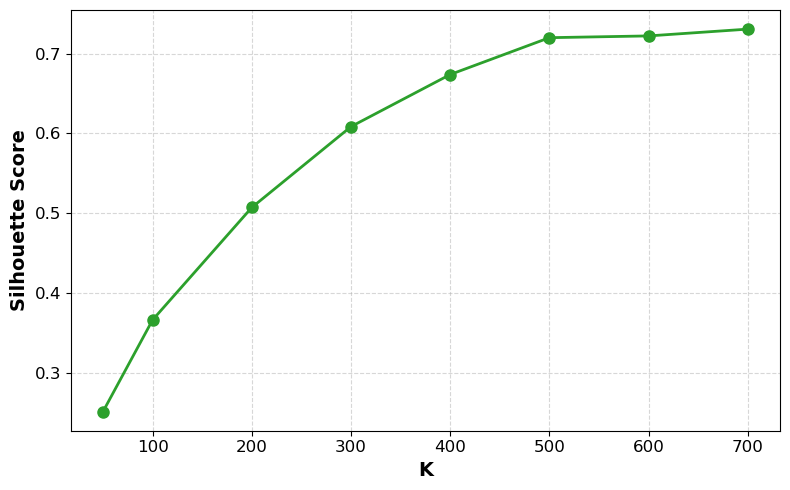

In [16]:
metric_values = [0.2514201,
 0.3663035,
 0.5071681,
 0.6084731,
 0.6737465,
 0.7199053,
 0.72211803,
 0.73062646]

metric_name = "Silhouette Score"


k_vals = k_values[:len(metric_values)]

plt.figure(figsize=(8, 5))

plt.plot(
    k_vals,
    metric_values,
    marker='o',
    linewidth=2,
    markersize=8,
    color='#2ca02c'
)

plt.xlabel('K', fontsize=14, fontweight='bold')
plt.ylabel(metric_name, fontsize=14, fontweight='bold')
# plt.title(metric_name, fontsize=16, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tick_params(axis='both', which='major', labelsize=12)

plt.tight_layout()
plt.savefig('silhouette.png', dpi=400, bbox_inches='tight')
print("Saved metrics plot: silhouette.png")
plt.show()
plt.close()